#### 1. Setup MODE
- Prints the repo root path (e.g.../Automation/ode-workflow)
  
- MODE options:
    - run_missing: skip runs that already have "run_summary.json" file
    - overwrite: rerun everything even if outputs exist
    - load_only: just read existing summaries (no simulation)

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))
print("repo_root:", repo_root)


import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib, hashlib, json as _json

from scripts.runner import runner, load_config

# -------------------------
# INPUT (edit only here)
# -------------------------

# Choose model: "Kapitanov", "Walz" or "Tiraboschi"
MODEL = "Tiraboschi" 

# Choose mode: "run_missing", "overwrite", "load_only"
MODE = "run_missing"

# Parallelism (good default for ~40 runs)
workers = 8  # adjust for your machine; 4–8 is typical

# -------------------------

# Map MODEL -> config path
MODEL_TO_CONFIG = {
    "Kapitanov": repo_root / "configs" / "Kapitanov_sweep.yaml",
    "Walz": repo_root / "configs" / "Walz_sweep.yaml",
    "Tiraboschi": repo_root / "configs" / "Tiraboschi_sweep.yaml",
}
config_path = MODEL_TO_CONFIG[MODEL]
print("Using config:", config_path)


repo_root: C:\Users\LevinSchöpfer\Automation\ode-workflow


C:\Temp\miniforge3\envs\ode-sim\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


ImportError: cannot import name 'runner' from 'scripts.runner' (C:\Users\LevinSchöpfer\Automation\ode-workflow\scripts\runner.py)

#### 2. Helper: list parameter-set folders
- Check which parameter runs already exist

In [19]:

def list_param_sets(base_root: Path, key_params=None) -> pd.DataFrame:
    """
    List available param-set folders under base_root (e.g., results/Walz_sweep).

    Expects each params_<id>/param_set.json manifest written by the runner.
    Returns a DataFrame sorted by created_at (if present).
    """
    base_root = Path(base_root)
    rows = []

    for pdir in sorted(base_root.glob("params_*")):
        manifest = pdir / "param_set.json"
        if not manifest.exists():
            continue

        try:
            data = json.loads(manifest.read_text(encoding="utf-8"))
        except Exception as e:
            rows.append({
                "param_id": pdir.name,
                "path": str(pdir),
                "created_at": None,
                "overrides": f"ERROR reading manifest: {e}",
            })
            continue

        overrides = data.get("param_overrides", {}) or {}
        eff = data.get("effective_params", {}) or {}

        row = {
            "param_id": pdir.name,
            "path": str(pdir),
            "created_at": data.get("created_at"),
            "n_overrides": len(overrides),
            "overrides": overrides,
        }

        # add selected key params for quick scanning
        if key_params:
            for k in key_params:
                row[k] = eff.get(k, None)

        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # sort newest first if timestamps exist
    if "created_at" in df.columns:
        df = df.sort_values("created_at", ascending=False, na_position="last").reset_index(drop=True)
    return df

cfg = load_config(config_path)
base_root = repo_root / cfg["output"]["root_dir"]

# choose a few key params to display (Walz example)
key_params = ["ka", "F", "Cl_ml_day", "Vmax_ugml_day", "Km_ugml", "IC50_ugml", "Imax", "kout"]

df_param_sets = list_param_sets(base_root, key_params=key_params)
df_param_sets.head(15)


""


#### 3. Define parameters + RUN
- Input:

    - dose_values in mg/kg
        - enter explicit list
        - use geometric distribution (lower boundtry, upper boundry, number of runs)
    - interval_values in weeks (integers only)


- Run:
    - Expected runs should match found runs
    - Prints missing items, if present 

In [42]:

# -------------------------
# INPUT
# -------------------------

dose_specification = [10, 500, 30]  # lower, upper, n
interval_values = [2, 4, 8, 12]  # weeks (int only)


# define parameter values # param_overrides = {} => baseline value from .yaml
param_overrides = { "Vmax_ugml_day": 15.0
    
}
# -------------------------
# RUN / LOAD
# -------------------------

def geometric_series(lower, upper, n, decimals=3):
    if lower <= 0 or upper <= 0:
        raise ValueError("Bounds must be > 0 for a geometric series.")
    if n < 2:
        raise ValueError("n must be at least 2.")
    r = (upper / lower) ** (1 / (n - 1))
    vals = [round(lower * r**i, decimals) for i in range(n)]
    vals = sorted(set(vals))
    return vals

dose_values = geometric_series(*dose_specification, decimals=3)

print("Dose values:", dose_values)
print("Intervals:", interval_values)

cfg = load_config(config_path)
model_module = importlib.import_module(cfg["model"]["module"])

def canonicalize_params(obj):
    if isinstance(obj, dict):
        return {k: canonicalize_params(obj[k]) for k in sorted(obj)}
    if isinstance(obj, (list, tuple)):
        return [canonicalize_params(x) for x in obj]
    if hasattr(obj, "item") and callable(obj.item):
        try:
            return obj.item()
        except Exception:
            pass
    if isinstance(obj, float):
        return float(f"{obj:.12g}")
    return obj

def params_fingerprint(params: dict) -> str:
    payload = _json.dumps(canonicalize_params(params), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:12]

effective_params = dict(getattr(model_module, "DEFAULTS", {}))
effective_params.update(cfg.get("params", {}))
if param_overrides:
    effective_params.update(param_overrides)

param_id = params_fingerprint(effective_params)

base_root = repo_root / cfg["output"]["root_dir"]
out_root = base_root / f"params_{param_id}"
print("Loading/running in:", out_root)

def load_all_summaries(out_root: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(out_root.glob("*/run_summary.json")):
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        d["_run_dir"] = str(p.parent)
        rows.append(d)
    return pd.DataFrame(rows)

def filter_to_grid_exact(df: pd.DataFrame, dose_values, interval_values) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["dose_mgkg"] = df["dose_mgkg"].astype(float)
    df["interval_weeks"] = df["interval_weeks"].astype(int)

    requested = set((float(d), int(i)) for d in dose_values for i in interval_values)
    mask = [(float(r.dose_mgkg), int(r.interval_weeks)) in requested for r in df.itertuples(index=False)]
    return df.loc[mask]

if MODE == "load_only":
    df_all = load_all_summaries(out_root)
else:
    df = runner(
        config_path=config_path,
        dose_values=dose_values,
        interval_values=interval_values,
        workers=workers,
        overwrite=(MODE=="overwrite"),
        param_overrides=param_overrides,
    )
    
    df_all = load_all_summaries(out_root)

df = filter_to_grid_exact(df_all, dose_values, interval_values)

if not df.empty:
    df["interval_weeks"] = df["interval_weeks"].astype(int)
    df = df.sort_values(["interval_weeks", "dose_mgkg"]).reset_index(drop=True)

df.head


# -------------------------
# COMPLETENESS CHECK
# -------------------------

expected = len(dose_values) * len(interval_values)
actual = len(df)
print("Expected runs:", expected)
print("Found runs:", actual)

if actual != expected:
    found = set((float(r.dose_mgkg), int(r.interval_weeks)) for r in df.itertuples(index=False))
    missing = [(float(d), int(i)) for d in dose_values for i in interval_values if (float(d), int(i)) not in found]
    print("Missing combos:", missing[:30], "..." if len(missing) > 30 else "")


Dose values: [10.0, 11.444, 13.097, 14.988, 17.153, 19.63, 22.465, 25.71, 29.423, 33.672, 38.535, 44.1, 50.469, 57.757, 66.099, 75.645, 86.569, 99.071, 113.379, 129.753, 148.492, 169.937, 194.479, 222.566, 254.709, 291.494, 333.591, 381.768, 436.903, 500.0]
Intervals: [2, 4, 8, 12]
Loading/running in: C:\Users\LevinSchöpfer\Automation\ode-workflow\results\Walz_sweep\params_56a99aca4d40
Expected runs: 120
Found runs: 120


#### 4. Plotting
- Plots key PD value over key PK value (Cavg / Ctrough)
- Prints utilized Parameter set at the bottom

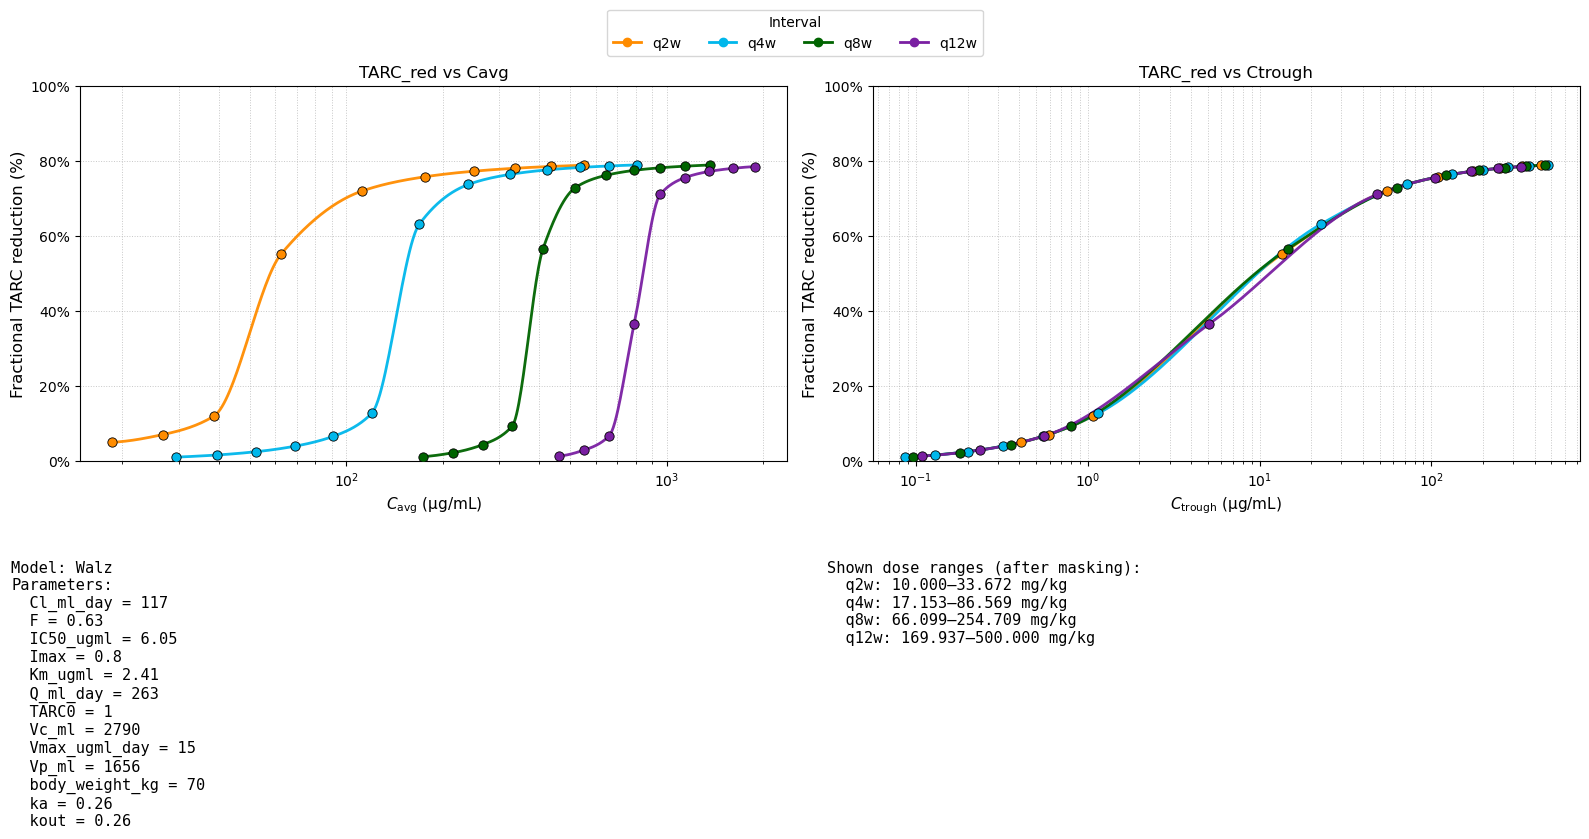

In [46]:

# Plotting-only thresholds (still defined in fractional units)
PD_MIN = 0.01
PD_MAX = 0.79

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, PercentFormatter
from scipy.interpolate import PchipInterpolator

if df.empty:
    raise RuntimeError("DataFrame `df` is empty. Run the sweep or load summaries first.")

# --- Detect PD trough column automatically ---
pd_candidates = [c for c in df.columns if c.endswith("_trough") and c not in ["C_trough_ugml"]]
if "RO3_trough" in pd_candidates:
    pd_col = "RO3_trough"
elif "TARC_red_trough" in pd_candidates:
    pd_col = "TARC_red_trough"
elif "EASI_red_trough" in pd_candidates:
    pd_col = "EASI_red_trough"
elif len(pd_candidates) == 1:
    pd_col = pd_candidates[0]
else:
    raise RuntimeError(f"Could not determine PD trough column uniquely. Candidates: {pd_candidates}")

# --- Automatic y-axis labeling ---
pd_key = cfg.get("outputs", {}).get("pd_key")

if pd_key == "RO3":
    y_title = "Fraction of occupied IL-4R at SoA"
elif pd_key == "TARC_red":
    y_title = "Fractional TARC reduction"
elif pd_key == "EASI_red":
    y_title = "Fractional EASI reduction"
else:
    y_title = pd_key

intervals = sorted(df["interval_weeks"].unique())

base_colors = ["#FF8C00", "#00B7EB", "#006400", "#7A1FA2"]
colors = [base_colors[i % len(base_colors)] for i in range(len(intervals))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
ax_left, ax_right = axes

# Smooth curve helper
def smooth_curve_logx(x, y, n_points=250):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = x > 0
    if mask.sum() < 2:
        return None, None

    x = x[mask]
    y = y[mask]

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    xu, inv = np.unique(x, return_inverse=True)
    if len(xu) != len(x):
        y_acc = np.zeros_like(xu, dtype=float)
        counts = np.zeros_like(xu, dtype=int)
        for i, idx in enumerate(inv):
            y_acc[idx] += y[i]
            counts[idx] += 1
        y = y_acc / counts
        x = xu

    if len(x) < 2:
        return None, None

    lx = np.log10(x)
    lx_smooth = np.linspace(lx.min(), lx.max(), n_points)
    f = PchipInterpolator(lx, y)
    y_smooth = f(lx_smooth)
    x_smooth = 10 ** lx_smooth
    return x_smooth, y_smooth


legend_handles = []
any_left = False
any_right = False

for idx, iw in enumerate(intervals):
    dfi = df[df["interval_weeks"] == iw].copy()
    color = colors[idx]

    # PD values
    y = dfi[pd_col].astype(float).values
    pd_mask = (y >= PD_MIN) & (y <= PD_MAX) & np.isfinite(y)

    # ---- Left: PD vs C_avg ----
    x_avg = dfi["C_avg_ugml"].astype(float).values
    mask_left = pd_mask & (x_avg > 0) & np.isfinite(x_avg)

    if mask_left.sum() >= 1:
        any_left = True
        y_percent = 100 * y[mask_left]

        xs, ys = smooth_curve_logx(x_avg[mask_left], y_percent)
        if xs is not None:
            ax_left.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)

        ax_left.scatter(
            x_avg[mask_left],
            y_percent,
            color=color,
            edgecolor="k",
            linewidth=0.6,
            s=45,
            zorder=3,
        )

    # ---- Right: PD vs C_trough ----
    x_tr = dfi["C_trough_ugml"].astype(float).values
    mask_right = pd_mask & (x_tr > 0) & np.isfinite(x_tr)

    if mask_right.sum() >= 1:
        any_right = True
        y_percent = 100 * y[mask_right]

        xs, ys = smooth_curve_logx(x_tr[mask_right], y_percent)
        if xs is not None:
            ax_right.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)

        ax_right.scatter(
            x_tr[mask_right],
            y_percent,
            color=color,
            edgecolor="k",
            linewidth=0.6,
            s=45,
            zorder=3,
        )

    legend_handles.append(
        plt.Line2D([0], [0], color=color, lw=2, marker="o", markersize=6, label=f"q{iw}w")
    )


# --- Axis formatting ---
for ax, has_any in [(ax_left, any_left), (ax_right, any_right)]:
    ax.set_ylim(0, 100)
    ax.grid(which="both", linestyle=":", linewidth=0.7, alpha=0.7)

    # percentage formatting + show ticks on both
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.tick_params(axis="y", labelleft=True)

    if has_any:
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(LogLocator(base=10))
        ax.xaxis.set_major_formatter(LogFormatterSciNotation())
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    else:
        # No data survived masking -> avoid log scaling crash
        ax.set_xscale("linear")
        ax.text(
            0.5, 0.5,
            "No points after masking",
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=12, alpha=0.7
        )

ax_left.set_title(f"{pd_key} vs Cavg", fontsize=12)
ax_right.set_title(f"{pd_key} vs Ctrough", fontsize=12)

ax_left.set_xlabel(r"$C_{\mathrm{avg}}$ (µg/mL)", fontsize=11)
ax_right.set_xlabel(r"$C_{\mathrm{trough}}$ (µg/mL)", fontsize=11)

ax_left.set_ylabel(y_title + " (%)", fontsize=12)
ax_right.set_ylabel(y_title + " (%)", fontsize=12)

fig.legend(handles=legend_handles,
           title="Interval",
           loc="upper center",
           ncol=len(intervals),
           bbox_to_anchor=(0.5, 1.03))

def format_param_summary(cfg, model_module, effective_params):
    lines = []

    # Model name
    lines.append(f"Model: {cfg['model']['name']}")

    # Parameters (sorted)
    lines.append("Parameters:")
    for k, v in sorted(effective_params.items()):
        if isinstance(v, float):
            lines.append(f"  {k} = {v:g}")
        else:
            lines.append(f"  {k} = {v}")

    # Microconstants (if available)
    if hasattr(model_module, "microconstants"):
        try:
            mcs = model_module.microconstants(effective_params)
            if mcs:
                lines.append("Microconstants:")
                for k, v in sorted(mcs.items()):
                    if isinstance(v, float):
                        lines.append(f"  {k} = {v:g}")
                    else:
                        lines.append(f"  {k} = {v}")
        except Exception as e:
            lines.append(f"Microconstants: error ({e})")

    return "\n".join(lines)


# Generate summary text
summary_text = format_param_summary(
    cfg=cfg,
    model_module=model_module,
    effective_params=effective_params,
)

# Determine PD trough column
pd_key = cfg.get("outputs", {}).get("pd_key")  # e.g. "RO3", "TARC_red", "EASI_red"
pd_trough_col = f"{pd_key}_trough"

# Generate dose range summary
ranges_text = format_dose_ranges_shown(
    df=df,
    intervals=intervals,
    pd_col=pd_trough_col,
    mask_min=PD_MIN,
    mask_max=PD_MAX,
    decimals=3,
)

# Place both text blocks under the plot
_ = fig.text(
    0.01, 0.1,
    summary_text,
    ha="left",
    va="top",
    fontsize=11,
    family="monospace",
)

_ = fig.text(
    0.52, 0.1,
    ranges_text,
    ha="left",
    va="top",
    fontsize=11,
    family="monospace",
)

plt.tight_layout(rect=[0, 0.15, 1, 0.95])
plt.show()
